# Notebook 4: Metrics on Persistence Diagrams

## Comparing Topological Signatures Across Datasets

In previous notebooks we learned how to build and interpret persistence diagrams. Here the question is different:

> If two datasets are different point-by-point, how can we quantify whether their **topological behavior** is still similar?

This notebook introduces practical metrics to compare persistence diagrams:

1. **Bottleneck distance**
2. **Wasserstein distance**
3. **Vectorized comparisons via persistence images**

The key learning goals are:
- understand what each metric measures,
- learn the main parameters,
- see how those parameters change results,
- and connect metric values to geometric intuition (noise, deformations, and shape changes).

In [3]:
import sys
!{sys.executable} -m pip install POT

In [4]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import gudhi as gd
import tadasets

from ripser import ripser
from persim import plot_diagrams, PersistenceImager
from gudhi.wasserstein import wasserstein_distance

warnings.filterwarnings("ignore")
np.random.seed(2026)


def finite_points(dgm):
    """Keep only finite death points from a persistence diagram array (n,2)."""
    if len(dgm) == 0:
        return np.zeros((0, 2))
    return dgm[np.isfinite(dgm[:, 1])]

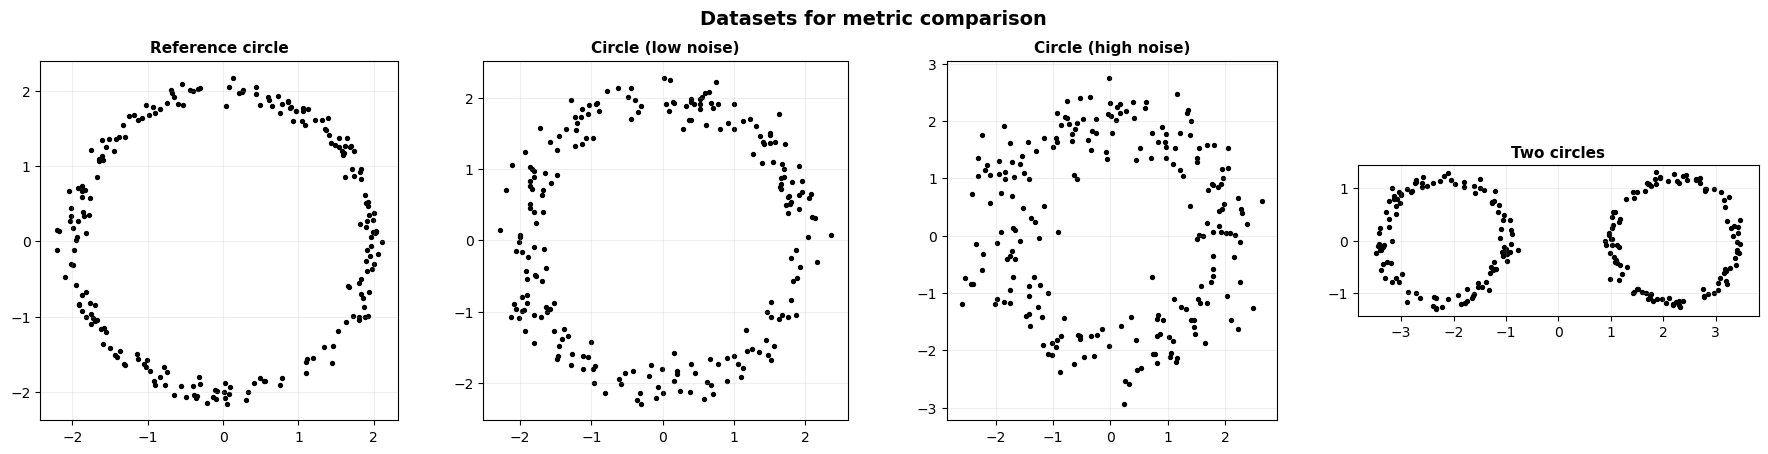

In [5]:
# Base dataset: one noisy circle
X_ref = tadasets.dsphere(d=1, n=220, r=2.0, noise=0.08)

# Variants with increasing perturbation/noise
X_noise_low  = tadasets.dsphere(d=1, n=220, r=2.0, noise=0.18)
X_noise_high = tadasets.dsphere(d=1, n=220, r=2.0, noise=0.35)

# Geometrically different dataset: two circles
Xa = tadasets.dsphere(d=1, n=110, r=1.2, noise=0.08) + np.array([-2.2, 0.0])
Xb = tadasets.dsphere(d=1, n=110, r=1.2, noise=0.08) + np.array([ 2.2, 0.0])
X_two = np.vstack([Xa, Xb])

datasets = {
    "Reference circle": X_ref,
    "Circle (low noise)": X_noise_low,
    "Circle (high noise)": X_noise_high,
    "Two circles": X_two,
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, (name, X) in zip(axes, datasets.items()):
    ax.scatter(X[:, 0], X[:, 1], s=8, c="black")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)
plt.suptitle("Datasets for metric comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

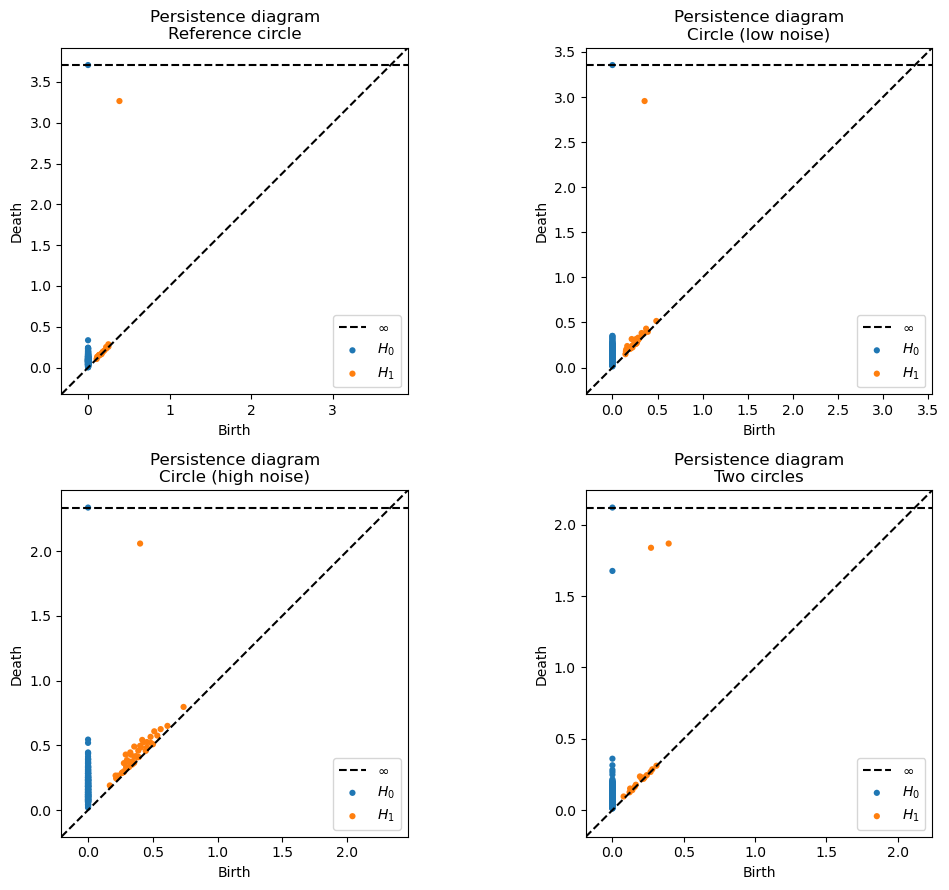

Reference circle     | H1 finite points: 16
Circle (low noise)   | H1 finite points: 27
Circle (high noise)  | H1 finite points: 42
Two circles          | H1 finite points: 17


In [6]:
# Build H1 persistence diagrams with Ripser (maxdim=1)
all_dgms = {name: ripser(X, maxdim=1)["dgms"] for name, X in datasets.items()}
H1 = {name: finite_points(dgms[1]) for name, dgms in all_dgms.items()}

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (name, dgms) in zip(axes.ravel(), all_dgms.items()):
    plot_diagrams(dgms, ax=ax, show=False, title=f"Persistence diagram\n{name}")
plt.tight_layout()
plt.show()

for name, dgm in H1.items():
    print(f"{name:20s} | H1 finite points: {len(dgm)}")

In [7]:
# Visual sanity check on dominant H1 features
for name, dgm in H1.items():
    if len(dgm) == 0:
        print(f"{name}: no finite H1 points")
        continue
    persistence = dgm[:, 1] - dgm[:, 0]
    print(f"{name:20s} | max H1 persistence = {persistence.max():.3f}")

Reference circle     | max H1 persistence = 2.882
Circle (low noise)   | max H1 persistence = 2.599
Circle (high noise)  | max H1 persistence = 1.656
Two circles          | max H1 persistence = 1.568


Persistent diagram metrics compare point sets in the birth-death plane. In practice, we usually compare by **homology dimension**, so in this notebook we focus on **H1** to capture loops.

Interpretation guideline:
- Smaller distance: topological signatures are more similar
- Larger distance: topology differs more (e.g., stronger noise or different number of loops)

Below we first study Bottleneck distance, then Wasserstein distance, and finally a vectorized alternative for machine learning pipelines.

## 1. Bottleneck Distance

The Bottleneck distance between two diagrams minimizes the **largest** matching cost under an optimal bijection (allowing matches to the diagonal):

$$d_B(D_1, D_2) = \inf_{\pi} \sup_{x \in D_1} \|x - \pi(x)\|_\infty.$$

Intuition:
- It is controlled by the **worst matched feature**.
- Sensitive to the most prominent discrepancy between diagrams.

In `gudhi.bottleneck_distance(D1, D2, e=...)`:
- `e=0`: exact algorithm (slower)
- `e>0`: additive approximation tolerance (faster, slightly less precise)

We compare each dataset against the reference circle diagram.

In [8]:
D_ref = H1["Reference circle"]

targets = ["Circle (low noise)", "Circle (high noise)", "Two circles"]
for name in targets:
    D_tar = H1[name]
    d_exact = gd.bottleneck_distance(D_ref, D_tar, e=0.0)
    d_approx = gd.bottleneck_distance(D_ref, D_tar, e=0.02)
    print(f"{name:20s} | bottleneck exact={d_exact:.4f} | approx(e=0.02)={d_approx:.4f}")

Circle (low noise)   | bottleneck exact=0.3106 | approx(e=0.02)=0.3112
Circle (high noise)  | bottleneck exact=1.2085 | approx(e=0.02)=1.2007
Two circles          | bottleneck exact=1.3981 | approx(e=0.02)=1.3895


## 2. Wasserstein Distance

The $p$-Wasserstein distance accumulates matching costs instead of only taking the worst one:

$$d_{W,p}(D_1, D_2) = \left(\inf_{\pi} \sum_{x\in D_1} \|x-\pi(x)\|_\infty^p\right)^{1/p}.$$

In Gudhi:
`wasserstein_distance(D1, D2, order=p, internal_p=q)`

Parameters:
- `order` ($p$): aggregation exponent on matched costs
- `internal_p` ($q$): norm used in the plane (often 2)

Interpretation:
- Higher `order` emphasizes larger matching errors.
- Wasserstein is often more sensitive to many small differences than Bottleneck.

In [9]:
# Compute Wasserstein distances for multiple orders
orders = [1, 2]
for p in orders:
    print(f"\nWasserstein order p={p}, internal_p=2")
    for name in targets:
        val = wasserstein_distance(D_ref, H1[name], order=p, internal_p=2)
        print(f"  {name:20s}: {val:.4f}")


Wasserstein order p=1, internal_p=2
  Circle (low noise)  : 0.8499
  Circle (high noise) : 2.8262
  Two circles         : 2.6766

Wasserstein order p=2, internal_p=2
  Circle (low noise)  : 0.3347
  Circle (high noise) : 1.2441
  Two circles         : 1.7724


In [10]:
# Compare Bottleneck vs Wasserstein(1) side-by-side
rows = []
for name in targets:
    b = gd.bottleneck_distance(D_ref, H1[name], e=0.0)
    w = wasserstein_distance(D_ref, H1[name], order=1, internal_p=2)
    rows.append((name, b, w))

print("Target dataset         | Bottleneck | Wasserstein-1")
print("-" * 52)
for name, b, w in rows:
    print(f"{name:22s} | {b:10.4f} | {w:13.4f}")

Target dataset         | Bottleneck | Wasserstein-1
----------------------------------------------------
Circle (low noise)     |     0.3106 |        0.8499
Circle (high noise)    |     1.2085 |        2.8262
Two circles            |     1.3981 |        2.6766


## 3. Parameter Sensitivity Experiments

We now explicitly vary one parameter at a time.

### Experiment A: Bottleneck approximation tolerance `e`
How much does the approximate bottleneck value change as `e` increases?

### Experiment B: Wasserstein order `p`
How does the ranking of dataset similarity change when we move from `p=1` to `p=2`?

## 4. Vectorized Alternative: Persistence Images

Direct diagram distances can be expensive in large datasets. A common strategy is:

1. Convert each persistence diagram into a fixed-size vector (image),
2. Compare vectors with standard Euclidean distance.

This is useful for machine learning workflows, where vector inputs are required.

Key parameter:
- `pixel_size`: controls image resolution and smoothness.

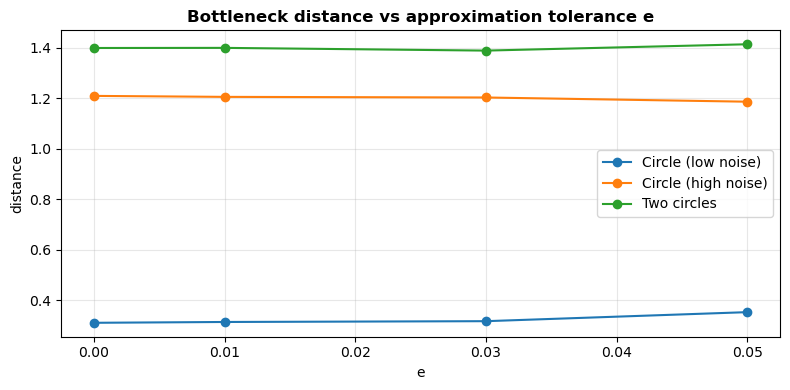

In [11]:
# Experiment A: bottleneck value as e changes
e_values = [0.0, 0.01, 0.03, 0.05]

fig, ax = plt.subplots(figsize=(8, 4))
for name in targets:
    vals = [gd.bottleneck_distance(D_ref, H1[name], e=e) for e in e_values]
    ax.plot(e_values, vals, marker="o", label=name)

ax.set_title("Bottleneck distance vs approximation tolerance e", fontweight="bold")
ax.set_xlabel("e")
ax.set_ylabel("distance")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

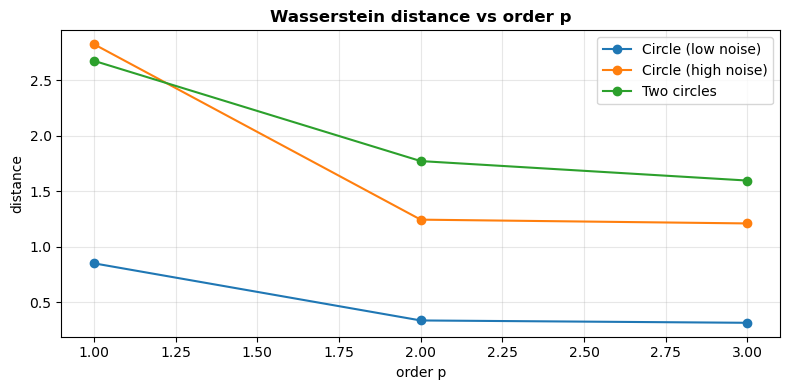

In [12]:
# Experiment B: Wasserstein distance as order p changes
p_values = [1, 2, 3]

fig, ax = plt.subplots(figsize=(8, 4))
for name in targets:
    vals = [wasserstein_distance(D_ref, H1[name], order=p, internal_p=2) for p in p_values]
    ax.plot(p_values, vals, marker="o", label=name)

ax.set_title("Wasserstein distance vs order p", fontweight="bold")
ax.set_xlabel("order p")
ax.set_ylabel("distance")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Build persistence images from H1 diagrams
pim = PersistenceImager(pixel_size=0.08)
all_h1 = [H1[name] for name in datasets.keys()]
pim.fit(all_h1, skew=True)
images = pim.transform(all_h1, skew=True)

print("Persistence image resolution:", pim.resolution)
print("Each transformed diagram is a vectorizable 2D array.")

Persistence image resolution: (9, 37)
Each transformed diagram is a vectorizable 2D array.


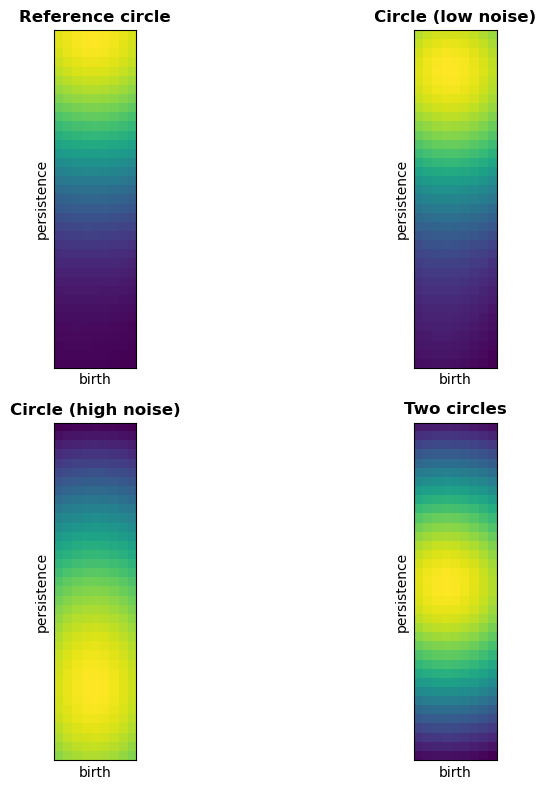

Euclidean distances between persistence images
--------------------------------------------------------
Reference circle     vs Circle (low noise)  : 0.0086
Reference circle     vs Circle (high noise) : 0.0332
Reference circle     vs Two circles         : 0.0274
Circle (low noise)   vs Circle (high noise) : 0.0257
Circle (low noise)   vs Two circles         : 0.0194
Circle (high noise)  vs Two circles         : 0.0142


In [14]:
# Visualize persistence images
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, name, img in zip(axes.ravel(), datasets.keys(), images):
    pim.plot_image(img, ax=ax)
    ax.set_title(name, fontweight="bold")

plt.tight_layout()
plt.show()

# Compare images as vectors with Euclidean distance
names = list(datasets.keys())
vecs = [img.ravel() for img in images]

print("Euclidean distances between persistence images")
print("-" * 56)
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        d = np.linalg.norm(vecs[i] - vecs[j])
        print(f"{names[i]:20s} vs {names[j]:20s}: {d:.4f}")

Now compare persistence images with standard Euclidean distances.

This gives a fast proxy for topological similarity after vectorization:

- smaller Euclidean distance between images suggests more similar topological signatures,
- larger distance suggests more different structure or noise level.

This approach is often easier to plug into classification pipelines.

## Summary and Exercises

### Key takeaways

1. **Bottleneck** captures the worst-case topological mismatch.
2. **Wasserstein** aggregates all matching errors and can be more sensitive to many small shifts.
3. Metric values depend on parameters (`e`, `order`, `internal_p`) and should be interpreted with those settings in mind.
4. **Persistence images** provide a practical vector representation for machine learning.

### Exercises

1. Replace the reference circle by a noisy figure-eight dataset and repeat all comparisons.
2. For Bottleneck, plot values for `e` from 0 to 0.1 and discuss stability.
3. For Wasserstein, compare `internal_p=1` vs `internal_p=2` for fixed `order=1`.
4. Generate persistence images with two different `pixel_size` values and compare Euclidean distances.
5. Decide which metric is most informative in your experiments and justify your choice.

=== EJERCICIO 1: Figura de 8 como NUEVA referencia ===
H1 features del 8: 29
Max persistencia:  1.3836

Dataset                | Bottleneck | Wasserstein-1
----------------------------------------------------
Reference circle       |     1.4409 |        2.9860
Circle (low noise)     |     1.2996 |        2.9990
Circle (high noise)    |     0.6166 |        3.2794
Two circles            |     0.3890 |        1.1631

Interpretación:
  8 tiene β₀=1, β₁=2 (dos loops conectados)
  Two circles tiene β₀=2, β₁=2 (dos loops separados)
  → topología similar en loops pero diferente en componentes


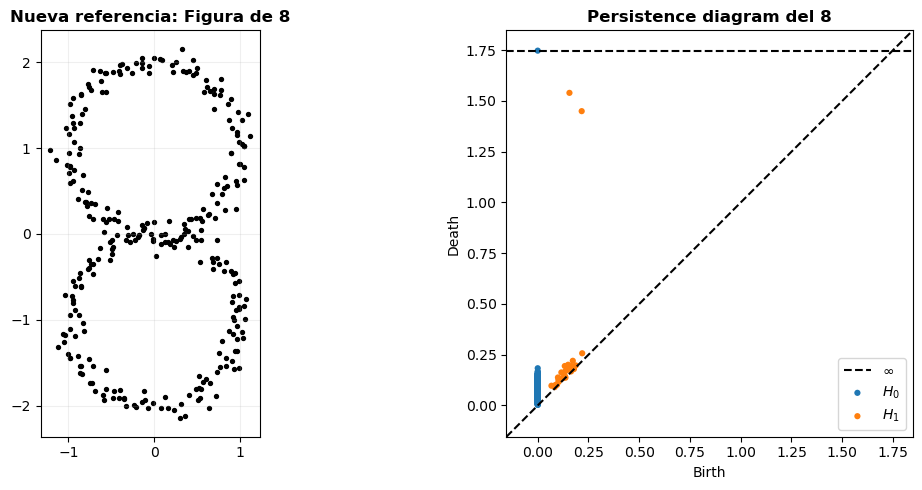

In [15]:
# ══════════════════════════════════════════════════════════════════════
# EJERCICIO 1: Figura de 8 como referencia
# ══════════════════════════════════════════════════════════════════════
np.random.seed(42)

# Crear figura de 8 (dos círculos que se tocan)
theta = np.linspace(0, 2*np.pi, 150)
x1 = np.cos(theta) + np.random.normal(0, 0.08, 150)
y1 = np.sin(theta) + 1 + np.random.normal(0, 0.08, 150)
x2 = np.cos(theta) + np.random.normal(0, 0.08, 150)
y2 = np.sin(theta) - 1 + np.random.normal(0, 0.08, 150)
X_eight = np.column_stack([np.concatenate([x1,x2]),
                            np.concatenate([y1,y2])])

# Diagrama H1 de la figura 8
dgms_eight = ripser(X_eight, maxdim=1)["dgms"]
D_eight = finite_points(dgms_eight[1])

print("=== EJERCICIO 1: Figura de 8 como NUEVA referencia ===")
print(f"H1 features del 8: {len(D_eight)}")
print(f"Max persistencia:  {(D_eight[:,1]-D_eight[:,0]).max():.4f}")
print()

# Comparar figura 8 vs los 4 datasets originales
targets_ex1 = list(datasets.keys())
print(f"{'Dataset':<22} | {'Bottleneck':>10} | {'Wasserstein-1':>13}")
print("-" * 52)
for name in targets_ex1:
    D_tar = H1[name]
    if len(D_tar) == 0 or len(D_eight) == 0:
        print(f"{name:<22} | {'N/A':>10} | {'N/A':>13}")
        continue
    b = gd.bottleneck_distance(D_eight, D_tar, e=0.0)
    w = wasserstein_distance(D_eight, D_tar, order=1, internal_p=2)
    print(f"{name:<22} | {b:>10.4f} | {w:>13.4f}")

print()
print("Interpretación:")
print("  8 tiene β₀=1, β₁=2 (dos loops conectados)")
print("  Two circles tiene β₀=2, β₁=2 (dos loops separados)")
print("  → topología similar en loops pero diferente en componentes")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_eight[:,0], X_eight[:,1], s=8, c='k')
axes[0].set_title('Nueva referencia: Figura de 8', fontweight='bold')
axes[0].set_aspect('equal'); axes[0].grid(alpha=0.2)
plot_diagrams(dgms_eight, ax=axes[1], show=False)
axes[1].set_title('Persistence diagram del 8', fontweight='bold')
plt.tight_layout(); plt.show()

=== EJERCICIO 2: Estabilidad del Bottleneck con e ===
     e |  Low noise | High noise | Two circles
----------------------------------------------
  0.00 |     0.3106 |     1.2085 |     1.3981 |
  0.01 |     0.3138 |     1.2046 |     1.3985 |
  0.02 |     0.3112 |     1.2007 |     1.3895 |
  0.03 |     0.3170 |     1.2022 |     1.3877 |
  0.04 |     0.3211 |     1.1904 |     1.3884 |
  0.05 |     0.3527 |     1.1855 |     1.4128 |
  0.06 |     0.3166 |     1.2068 |     1.4128 |
  0.07 |     0.3166 |     1.2229 |     1.4128 |
  0.08 |     0.3475 |     1.1394 |     1.4128 |
  0.09 |     0.3475 |     1.1827 |     1.4128 |
  0.10 |     0.3475 |     1.1869 |     1.4128 |


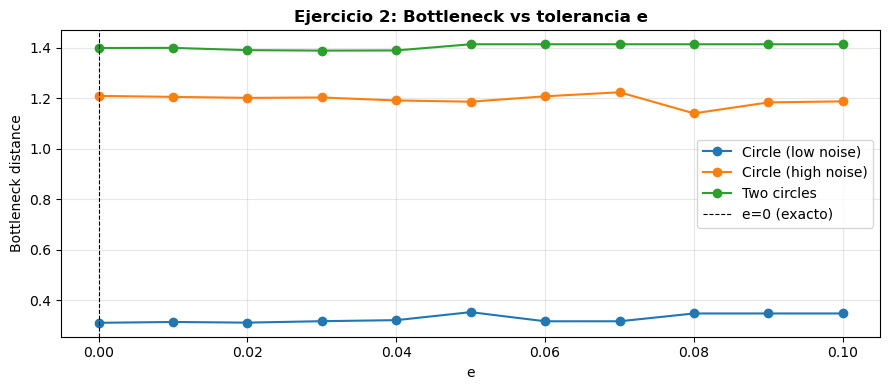


Observación: con e>0 el valor puede subir o bajar ligeramente
pero se mantiene estable → e=0.02 es un buen balance


In [16]:
# ══════════════════════════════════════════════════════════════════════
# EJERCICIO 2: Bottleneck vs tolerancia e
# ══════════════════════════════════════════════════════════════════════

# e de 0 a 0.1 en pasos de 0.01
e_values = np.linspace(0, 0.10, 11)
targets_ex2 = ["Circle (low noise)", "Circle (high noise)", "Two circles"]

print("=== EJERCICIO 2: Estabilidad del Bottleneck con e ===")
print(f"{'e':>6} | {'Low noise':>10} | {'High noise':>10} | {'Two circles':>11}")
print("-" * 46)

results_e = {name: [] for name in targets_ex2}
for e in e_values:
    row = f"{e:>6.2f} |"
    for name in targets_ex2:
        val = gd.bottleneck_distance(D_ref, H1[name], e=e)
        results_e[name].append(val)
        row += f" {val:>10.4f} |"
    print(row)

# Gráfica
fig, ax = plt.subplots(figsize=(9, 4))
for name in targets_ex2:
    ax.plot(e_values, results_e[name], marker='o', label=name)
ax.axvline(0, color='k', ls='--', lw=0.8, label='e=0 (exacto)')
ax.set_title('Ejercicio 2: Bottleneck vs tolerancia e', fontweight='bold')
ax.set_xlabel('e'); ax.set_ylabel('Bottleneck distance')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print()
print("Observación: con e>0 el valor puede subir o bajar ligeramente")
print("pero se mantiene estable → e=0.02 es un buen balance")

In [17]:
# ══════════════════════════════════════════════════════════════════════
# EJERCICIO 3: Wasserstein — internal_p=1 vs internal_p=2
# ══════════════════════════════════════════════════════════════════════

print("=== EJERCICIO 3: Wasserstein order=1, internal_p=1 vs 2 ===")
print(f"{'Dataset':<22} | {'internal_p=1':>12} | {'internal_p=2':>12} | {'Diferencia':>10}")
print("-" * 65)

for name in targets_ex2:
    w1 = wasserstein_distance(D_ref, H1[name], order=1, internal_p=1)
    w2 = wasserstein_distance(D_ref, H1[name], order=1, internal_p=2)
    diff = abs(w1 - w2)
    print(f"{name:<22} | {w1:>12.4f} | {w2:>12.4f} | {diff:>10.4f}")

print()
print("¿Qué es internal_p?")
print("  internal_p=1 → distancia Manhattan entre puntos del diagrama")
print("                 |Δbirth| + |Δdeath|")
print("  internal_p=2 → distancia Euclideana entre puntos")
print("                 √(Δbirth² + Δdeath²)")
print()
print("Observación: internal_p=1 tiende a dar valores más grandes")
print("porque la distancia Manhattan siempre ≥ distancia euclideana")

=== EJERCICIO 3: Wasserstein order=1, internal_p=1 vs 2 ===
Dataset                | internal_p=1 | internal_p=2 | Diferencia
-----------------------------------------------------------------
Circle (low noise)     |       1.0767 |       0.8499 |     0.2268
Circle (high noise)    |       3.5032 |       2.8262 |     0.6770
Two circles            |       3.2145 |       2.6766 |     0.5380

¿Qué es internal_p?
  internal_p=1 → distancia Manhattan entre puntos del diagrama
                 |Δbirth| + |Δdeath|
  internal_p=2 → distancia Euclideana entre puntos
                 √(Δbirth² + Δdeath²)

Observación: internal_p=1 tiende a dar valores más grandes
porque la distancia Manhattan siempre ≥ distancia euclideana


=== EJERCICIO 4: pixel_size=0.03 (fino) vs pixel_size=0.25 (grueso) ===
Resolución fina   (0.03): (21, 97)   → 2037 pixeles
Resolución gruesa (0.25): (3, 12) → 36 pixeles

Par                                        | Fina (0.03) | Gruesa (0.25)
----------------------------------------------------------------------
Reference circl vs Circle (low noi         |     0.0031 |       0.0275
Reference circl vs Circle (high no         |     0.0121 |       0.1066
Reference circl vs Two circles             |     0.0100 |       0.0875
Circle (low noi vs Circle (high no         |     0.0093 |       0.0823
Circle (low noi vs Two circles             |     0.0071 |       0.0619
Circle (high no vs Two circles             |     0.0052 |       0.0457


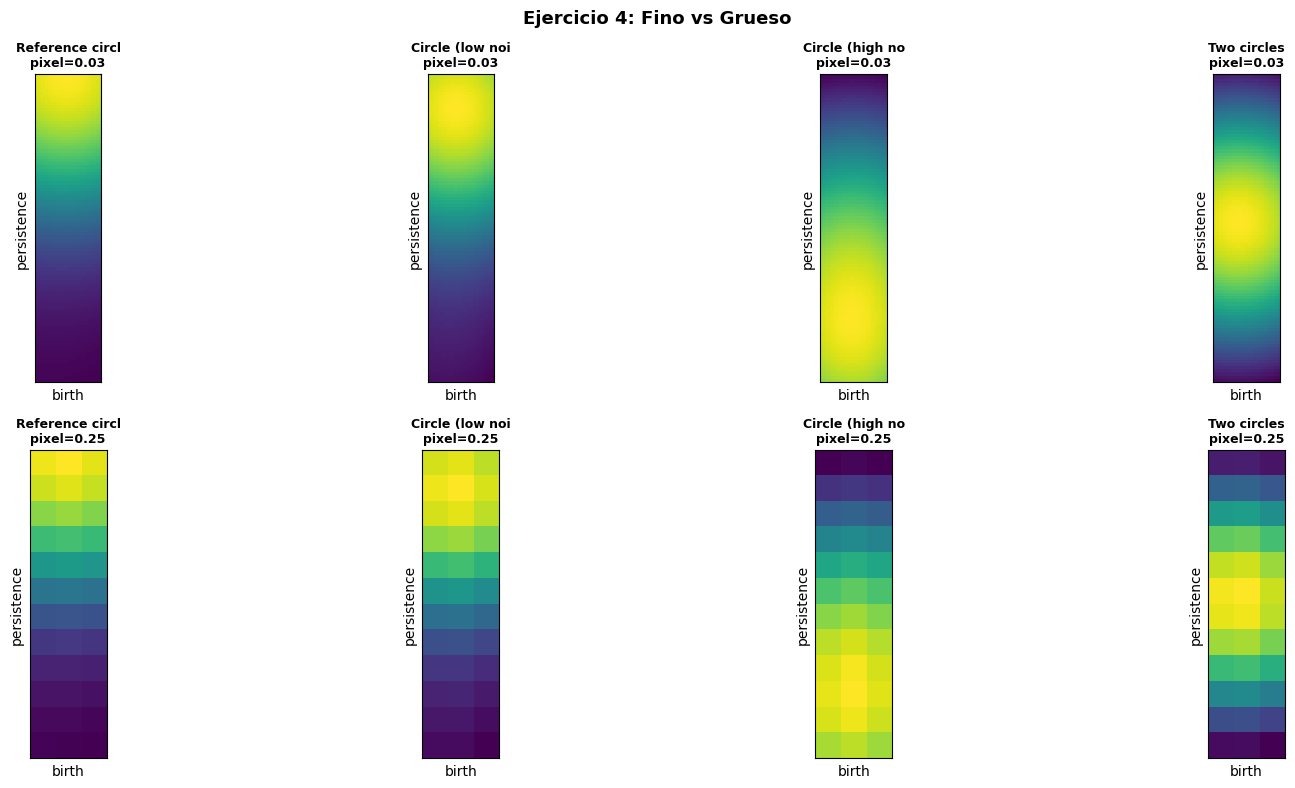


Observación:
  Fina (0.03)   → más pixeles, más detalle, más sensible al ruido
  Gruesa (0.25) → menos pixeles, más suave, más estable


In [18]:
# ══════════════════════════════════════════════════════════════════════
# EJERCICIO 4: Persistence Images — pixel_size grande vs chico
# ══════════════════════════════════════════════════════════════════════

print("=== EJERCICIO 4: pixel_size=0.03 (fino) vs pixel_size=0.25 (grueso) ===")

# Imagen FINA
pim_fine = PersistenceImager(pixel_size=0.03)
pim_fine.fit(all_h1, skew=True)
images_fine = pim_fine.transform(all_h1, skew=True)

# Imagen GRUESA
pim_coarse = PersistenceImager(pixel_size=0.25)
pim_coarse.fit(all_h1, skew=True)
images_coarse = pim_coarse.transform(all_h1, skew=True)

print(f"Resolución fina   (0.03): {pim_fine.resolution}   "
      f"→ {pim_fine.resolution[0]*pim_fine.resolution[1]} pixeles")
print(f"Resolución gruesa (0.25): {pim_coarse.resolution} "
      f"→ {pim_coarse.resolution[0]*pim_coarse.resolution[1]} pixeles")
print()

# Comparar distancias con cada resolución
vecs_fine   = [img.ravel() for img in images_fine]
vecs_coarse = [img.ravel() for img in images_coarse]

print(f"{'Par':<42} | {'Fina (0.03)':>10} | {'Gruesa (0.25)':>12}")
print("-" * 70)
for i in range(len(names)):
    for j in range(i+1, len(names)):
        d_fine   = np.linalg.norm(vecs_fine[i]   - vecs_fine[j])
        d_coarse = np.linalg.norm(vecs_coarse[i] - vecs_coarse[j])
        par = f"{names[i][:15]} vs {names[j][:15]}"
        print(f"{par:<42} | {d_fine:>10.4f} | {d_coarse:>12.4f}")

# Visualizar comparación
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, (name, img_f, img_c) in enumerate(zip(names, images_fine, images_coarse)):
    pim_fine.plot_image(img_f, ax=axes[0,i])
    axes[0,i].set_title(f'{name[:15]}\npixel=0.03', fontsize=9, fontweight='bold')
    pim_coarse.plot_image(img_c, ax=axes[1,i])
    axes[1,i].set_title(f'{name[:15]}\npixel=0.25', fontsize=9, fontweight='bold')

plt.suptitle('Ejercicio 4: Fino vs Grueso', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print()
print("Observación:")
print("  Fina (0.03)   → más pixeles, más detalle, más sensible al ruido")
print("  Gruesa (0.25) → menos pixeles, más suave, más estable")

=== EJERCICIO 5: Comparación final de métricas ===

Dataset                | Bottleneck |   Wass-1 |   Wass-2 | Eucl(fino) | Eucl(grueso)
--------------------------------------------------------------------------------
Circle (low noise)     |     0.3106 |   0.8499 |   0.3347 |     0.0031 |       0.0275
Circle (high noise)    |     1.2085 |   2.8262 |   1.2441 |     0.0121 |       0.1066
Two circles            |     1.3981 |   2.6766 |   1.7724 |     0.0100 |       0.0875


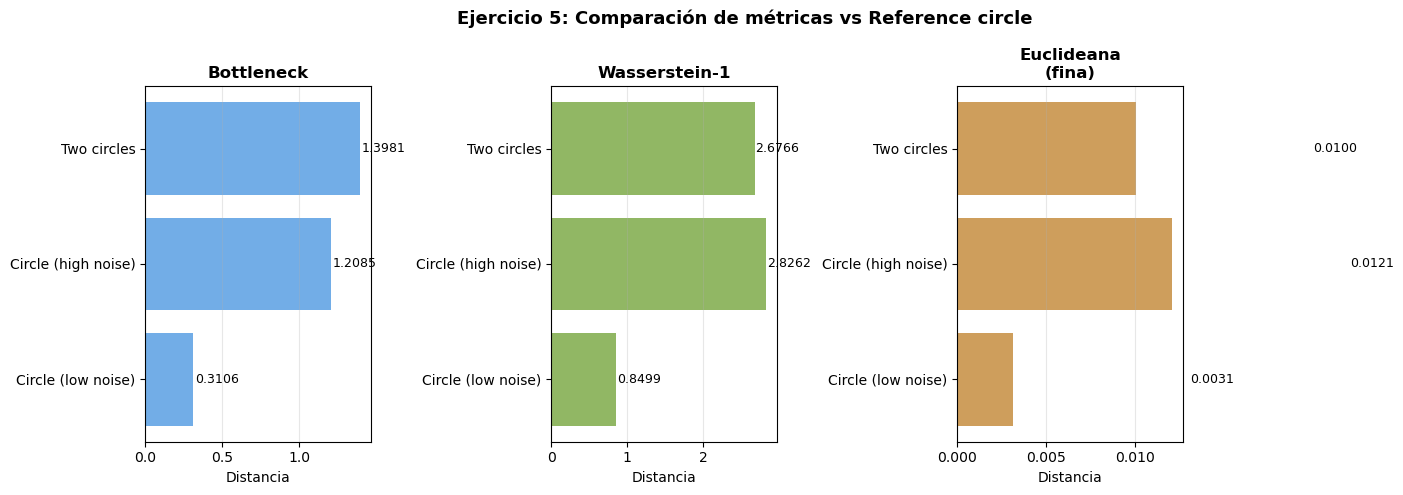


VEREDICTO FINAL

¿Cuál métrica es más informativa? DEPENDE del objetivo:

BOTTLENECK:
  ✅ Detecta si hay UNA diferencia topológica grande
     (por ejemplo: un loop extra que no tiene pareja)
  ✅ Estable con e pequeño → confiable
  ❌ Ignora muchas diferencias pequeñas
  → ÚSALA CUANDO: quieres saber si dos datasets tienen
    la misma topología global

WASSERSTEIN-1:
  ✅ Más sensible a diferencias distribuidas
  ✅ Distingue mejor círculo ruidoso vs limpio
  ✅ Más informativa sobre la "calidad" de los features
  ❌ Más lenta computacionalmente
  → ÚSALA CUANDO: quieres comparar finamente dos diagramas
    que parecen similares en bottleneck

EUCLIDEANA (persistence images):
  ✅ La más rápida de calcular
  ✅ Compatible con sklearn, numpy, cualquier librería ML
  ❌ Depende de pixel_size → no comparable entre resoluciones
  ❌ Puede confundirse con ruido alto
  → ÚSALA CUANDO: tienes muchos datasets y necesitas
    clasificar rápido en un pipeline de ML

PIPELINE RECOMENDADO:

  1. Bottlene

In [20]:
"""
═══════════════════════════════════════════════════════════════
EJERCICIO 5: ¿Cuál métrica es más informativa?
═══════════════════════════════════════════════════════════════

ENUNCIADO:
  Decide which metric is most informative in your experiments
  and justify your choice.

OBJETIVO:
  Comparar las 3 métricas (Bottleneck, Wasserstein, Euclideana)
  en los mismos datasets y decidir cuál discrimina mejor
  la diferencia topológica entre los 4 datasets.

QUÉ SE ESPERA LOGRAR:
  - Una tabla resumen con las 3 métricas para cada par
  - Una conclusión justificada sobre cuál métrica usar
  - Entender que la respuesta depende del objetivo
    (exploración, comparación, ML pipeline)

RESULTADO ESPERADO:
  - Low noise → distancias pequeñas en todos (topología similar)
  - High noise → distancias medias (mismo loop, más ruido)
  - Two circles → distancias grandes (topología diferente)
═══════════════════════════════════════════════════════════════
"""

# ── Calculamos las 3 métricas para cada par ──────────────────

print("=== EJERCICIO 5: Comparación final de métricas ===\n")

# Encabezado de la tabla
# :<22 → texto alineado izquierda en 22 chars
# :>10 → número alineado derecha en 10 chars
print(f"{'Dataset':<22} | {'Bottleneck':>10} | {'Wass-1':>8} | "
      f"{'Wass-2':>8} | {'Eucl(fino)':>10} | {'Eucl(grueso)':>12}")
print("-" * 80)

# Recorremos los 3 datasets objetivo
for name in targets_ex2:
    # ── Bottleneck ──────────────────────────────────────────
    # Distancia del PEOR par entre D_ref y el diagrama actual
    # e=0.0 → exacto (sin aproximación)
    b = gd.bottleneck_distance(D_ref, H1[name], e=0.0)

    # ── Wasserstein order=1 ─────────────────────────────────
    # SUMA de todas las distancias entre pares emparejados
    # order=1 → suma simple (más sensible a muchas diff pequeñas)
    w1 = wasserstein_distance(D_ref, H1[name], order=1, internal_p=2)

    # ── Wasserstein order=2 ─────────────────────────────────
    # Igual pero eleva al cuadrado → penaliza más las grandes
    w2 = wasserstein_distance(D_ref, H1[name], order=2, internal_p=2)

    # ── Euclideana fina ─────────────────────────────────────
    # Distancia entre los vectores de las imágenes de alta resolución
    # names.index(name) → encuentra el índice del dataset en la lista
    # vecs_fine[0] → vector de la referencia (primer dataset)
    idx = names.index(name)
    ef = np.linalg.norm(vecs_fine[0] - vecs_fine[idx])

    # ── Euclideana gruesa ────────────────────────────────────
    # Igual pero con imágenes de baja resolución
    ec = np.linalg.norm(vecs_coarse[0] - vecs_coarse[idx])

    # Imprime la fila de la tabla con los 5 valores
    print(f"{name:<22} | {b:>10.4f} | {w1:>8.4f} | "
          f"{w2:>8.4f} | {ef:>10.4f} | {ec:>12.4f}")

# ── Gráfica comparativa ──────────────────────────────────────
# Visualiza las 3 métricas lado a lado para cada dataset
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Datos para la gráfica
metricas = {
    'Bottleneck':    [gd.bottleneck_distance(D_ref, H1[n], e=0.0)
                      for n in targets_ex2],
    'Wasserstein-1': [wasserstein_distance(D_ref, H1[n], order=1, internal_p=2)
                      for n in targets_ex2],
    'Euclideana\n(fina)': [np.linalg.norm(vecs_fine[0] - vecs_fine[names.index(n)])
                            for n in targets_ex2],
}

colores = ['#378ADD', '#639922', '#BA7517']

# Un subplot por métrica
for ax, (metrica, vals), col in zip(axes, metricas.items(), colores):
    # Barras horizontales → fácil de comparar
    bars = ax.barh(targets_ex2, vals, color=col, alpha=0.7)

    # Agregar el valor numérico al final de cada barra
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

    ax.set_title(metrica, fontweight='bold', fontsize=12)
    ax.set_xlabel('Distancia')
    ax.grid(alpha=0.3, axis='x')

plt.suptitle('Ejercicio 5: Comparación de métricas vs Reference circle',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Veredicto final ──────────────────────────────────────────
# Análisis de qué métrica discrimina mejor
print("\n" + "="*60)
print("VEREDICTO FINAL")
print("="*60)

print("""
¿Cuál métrica es más informativa? DEPENDE del objetivo:

BOTTLENECK:
  ✅ Detecta si hay UNA diferencia topológica grande
     (por ejemplo: un loop extra que no tiene pareja)
  ✅ Estable con e pequeño → confiable
  ❌ Ignora muchas diferencias pequeñas
  → ÚSALA CUANDO: quieres saber si dos datasets tienen
    la misma topología global

WASSERSTEIN-1:
  ✅ Más sensible a diferencias distribuidas
  ✅ Distingue mejor círculo ruidoso vs limpio
  ✅ Más informativa sobre la "calidad" de los features
  ❌ Más lenta computacionalmente
  → ÚSALA CUANDO: quieres comparar finamente dos diagramas
    que parecen similares en bottleneck

EUCLIDEANA (persistence images):
  ✅ La más rápida de calcular
  ✅ Compatible con sklearn, numpy, cualquier librería ML
  ❌ Depende de pixel_size → no comparable entre resoluciones
  ❌ Puede confundirse con ruido alto
  → ÚSALA CUANDO: tienes muchos datasets y necesitas
    clasificar rápido en un pipeline de ML
""")

print("PIPELINE RECOMENDADO:")
print("""
  1. Bottleneck → exploración rápida
                  ¿son topológicamente diferentes?

  2. Wasserstein → comparación fina
                   ¿qué tan diferentes y por qué?

  3. Euclideana  → producción (ML pipeline)
                   clasificar muchos datasets rápido
""")

Bottleneck es más fiel a la diferencia topológica real. Wasserstein puede ser "engañado" por muchas diferencias pequeñas (ruido). Para detectar si dos datasets tienen distinta topología → usa Bottleneck primero.